# Commit-level breaking changes vs. released JARs

For each of the 29 studied libraries this notebook recovers the releases from Maven Central,
locates the commit each release was cut from inside the walked history, and compares three views of
every interval between two consecutive releases:

| | what it is | modality | granularity |
|---|---|---|---|
| **C** | the walk's per-commit breaking changes, summed over the interval | source | incremental |
| **S** | one Roseau diff between the two anchor commits | source | cumulative |
| **R** | one Roseau diff between the two released JARs | bytecode | cumulative |

`S` sits between the two and splits the `C`-to-`R` gap into the part caused by *granularity*
(`C` vs `S`) and the part caused by *modality and what was actually shipped* (`S` vs `R`).

The second is what this notebook is for: whether Roseau's source and bytecode models agree on real
artefacts. `C` vs `R` is not a clean measurement of granularity, because it also mixes in releases
cut off the default branch, artefacts built from source roots the walk does not cover, and
build-time transformation of the JAR; `commit_vs_tag.ipynb` measures granularity alone.

Regenerate the inputs with [`benchmark/releases`](../../benchmark/releases/).

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_rows", 100)
plt.rcParams["figure.figsize"] = (12, 6)

# Categorical slots 1-3 of the validated reference palette, used in fixed order.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"

DATA_DIR = Path("data")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

releases = pd.read_csv(DATA_DIR / "releases-anchored.csv")
intervals = pd.read_csv(DATA_DIR / "intervals.csv")
comparison = pd.read_csv(DATA_DIR / "comparison-tagged.csv")
comparison_all = pd.read_csv(DATA_DIR / "comparison-all.csv")
comparison_erased = pd.read_csv(DATA_DIR / "comparison-tagged-erased.csv")

len(releases), len(intervals), len(comparison)

(2645, 1463, 1240)

## 1. Locating releases in the walked history

Every stable release published inside a library's walked date range is anchored on the
first-parent history the walk visited:

- `tag_exact` — the release's Git tag *is* a walked commit;
- `tag_ancestor` — the tag lives off the walked line (a release branch, or a topic branch that was
  merged), so the anchor is the newest walked commit that is an ancestor of the tag;
- `timestamp` — no tag matches the version, so the anchor is the last walked commit that predates
  publication on Maven Central;
- `out_of_range` — the artefact was published outside the walked window.

In [2]:
anchor_summary = (releases.groupby("anchor_method").size()
                  .rename("releases").to_frame()
                  .assign(share=lambda d: (d.releases / d.releases.sum()).map("{:.1%}".format)))
display(anchor_summary)

lag = releases.loc[releases.anchor_method.isin(["tag_exact", "tag_ancestor"]), :]
display(lag.groupby("anchor_method").anchor_lag_days
        .describe(percentiles=[0.5, 0.9])[["count", "50%", "90%", "max"]].round(1))

,releases,share
anchor_method,,
out_of_range,143,5.4%
tag_ancestor,1312,49.6%
tag_exact,910,34.4%
timestamp,280,10.6%


,count,50%,90%,max
anchor_method,,,,
tag_ancestor,1312.0,130.6,1691.8,3469.0
tag_exact,910.0,0.0,0.9,2876.8


The `tag_ancestor` lag is telling: the median release anchored this way was cut from a commit
**months** behind the mainline, because it comes off a maintenance branch. Spring's 6.2.x line
branched in November 2024 and keeps shipping; Jackson's 2.x line branched in 2017. A first-parent
walk of one branch does not visit the commits those releases are built from.

That is why the release chain is restricted to the **mainline**: releases are taken in publication
order and kept only when both the anchor *and* the version number move forward. What this drops is
exactly the off-mainline maintenance releases.

In [3]:
per_lib = (releases.groupby("library")
           .agg(stable_releases=("version", "size"))
           .join(intervals.groupby("library")
                 .agg(intervals=("pair_id", "size"),
                      tag_anchored=("tag_anchored", "sum"),
                      commits=("commits_in_interval", "sum"))))
per_lib["off_mainline_share"] = 1 - (per_lib.intervals + 1) / per_lib.stable_releases
display(per_lib.sort_values("stable_releases", ascending=False))

display(Markdown(
    f"**{len(releases)}** stable releases anchored, of which "
    f"**{len(intervals) + releases.library.nunique()}** sit on a mainline release chain; "
    f"**{len(intervals)}** consecutive intervals covering "
    f"**{intervals.commits_in_interval.sum():,}** of the walk's 186,946 commits. "
    f"**{int(intervals.tag_anchored.sum())}** intervals have *both* endpoints located by a Git tag "
    f"— those are the primary analysis set."))

,stable_releases,intervals,tag_anchored,commits,off_mainline_share
library,,,,,
spring-context,314,80,78,27866,0.742038
mockito-core,216,210,206,4398,0.023148
jackson-databind,213,41,41,6308,0.802817
jackson-core,171,40,35,2540,0.760234
fastjson,157,61,57,4587,0.605096
logback-classic,155,114,96,3836,0.258065
protobuf-java,149,63,31,12814,0.570470
h2,140,112,27,7984,0.192857
mysql-connector-j,105,38,37,1209,0.628571


**2645** stable releases anchored, of which **1492** sit on a mainline release chain; **1463** consecutive intervals covering **148,319** of the walk's 186,946 commits. **1240** intervals have *both* endpoints located by a Git tag — those are the primary analysis set.

## 2. How much of the commit-level signal survives to a release?

`comparison-tagged.csv` has one row per interval. Breaking changes are identified by
`(kind, impacted_symbol_fqn)`; `commit_events` counts the walk's raw rows, `commit_keys` the
distinct breaking changes behind them.

In [4]:
def summarise(df):
    g = df.groupby("library").agg(
        intervals=("pair_id", "size"),
        commits=("commits_in_interval", "sum"),
        C_events=("commit_events", "sum"),
        C=("commit_keys", "sum"),
        S=("source_keys", "sum"),
        R=("release_keys", "sum"),
        CR=("commit_and_release", "sum"),
        SR=("source_and_release", "sum"))
    total = g.sum().rename("ALL")
    g = pd.concat([g, total.to_frame().T])
    g["events_per_released_bc"] = (g.C_events / g.R).round(2)
    g["survival_CR_over_C"] = (g.CR / g.C).round(3)
    g["coverage_CR_over_R"] = (g.CR / g.R).round(3)
    g["coverage_SR_over_R"] = (g.SR / g.R).round(3)
    return g


usable = comparison[comparison.has_jar_diff & comparison.has_source_diff]
table = summarise(usable)
display(table)

,intervals,commits,C_events,C,S,R,CR,SR,events_per_released_bc,survival_CR_over_C,coverage_CR_over_R,coverage_SR_over_R
assertj-core,64,3265,14823,4856,4407,4859,4223,4232,3.05,0.870,0.869,0.871
commons-beanutils,16,992,599,404,246,213,213,213,2.81,0.527,1.000,1.000
commons-codec,23,3156,567,478,24,24,23,24,23.62,0.048,0.958,1.000
commons-collections,7,3353,7303,4325,372,336,336,336,21.74,0.078,1.000,1.000
commons-io,30,4981,1020,659,106,105,105,105,9.71,0.159,1.000,1.000
commons-lang,31,8203,2061,1845,209,127,122,122,16.23,0.066,0.961,0.961
commons-logging,13,1215,8,7,7,7,7,7,1.14,1.000,1.000,1.000
fastjson,57,4393,1874,1355,1042,984,967,980,1.90,0.714,0.983,0.996
gson,25,880,2,2,0,1,0,0,2.00,0.000,0.000,0.000
guava,53,6529,444,423,84,80,80,80,5.55,0.189,1.000,1.000


In [5]:
row = table.loc["ALL"]
display(Markdown(f"""
Over **{len(usable)}** tag-anchored intervals spanning **{int(row.commits):,}** commits:

- the walk records **{int(row.C_events):,}** public-API breaking-change events
  (**{int(row.C):,}** distinct breaking changes);
- Roseau finds **{int(row.R):,}** distinct breaking changes between the corresponding released JARs;
- that is **{row.C_events / row.R:.1f} commit-level events per released breaking change**;
- **{row.CR / row.C:.1%}** of the distinct commit-level breaking changes are still observable
  between the two releases;
- **{row.CR / row.R:.1%}** of the released breaking changes are attributable to a walked commit.
"""))


Over **1233** tag-anchored intervals spanning **117,048** commits:

- the walk records **223,676** public-API breaking-change events
  (**54,480** distinct breaking changes);
- Roseau finds **25,504** distinct breaking changes between the corresponding released JARs;
- that is **8.8 commit-level events per released breaking change**;
- **36.2%** of the distinct commit-level breaking changes are still observable
  between the two releases;
- **77.4%** of the released breaking changes are attributable to a walked commit.


In [6]:
per_interval = usable[usable.release_keys > 0]
display(Markdown(f"""
Per interval rather than in aggregate (the aggregate is dominated by a few very large intervals):

- median `commit_keys / release_keys` = **{(per_interval.commit_keys / per_interval.release_keys).median():.2f}**
- median survival `C∩R / C` = **{(usable[usable.commit_keys > 0].commit_and_release
                                  / usable[usable.commit_keys > 0].commit_keys).median():.2f}**
- **{(usable.release_keys > 0).mean():.1%}** of intervals ship at least one breaking change,
  while **{(usable.commit_keys > 0).mean():.1%}** contain at least one commit-level breaking change
- **{int(((usable.release_keys == 0) & (usable.commit_keys > 0)).sum())}** intervals contain
  commit-level breaking changes but ship none
"""))


Per interval rather than in aggregate (the aggregate is dominated by a few very large intervals):

- median `commit_keys / release_keys` = **1.02**
- median survival `C∩R / C` = **0.69**
- **40.7%** of intervals ship at least one breaking change,
  while **47.2%** contain at least one commit-level breaking change
- **102** intervals contain
  commit-level breaking changes but ship none


## 3. Where does the gap come from?

`S` — one cumulative source diff between the two anchor commits — separates the two candidate
explanations. If the gap were caused by the walk's *granularity* (churn that cancels out over an
interval), `S` would sit close to `R`. If it were caused by *modality* (bytecode vs. source), `S`
would sit close to `C`.

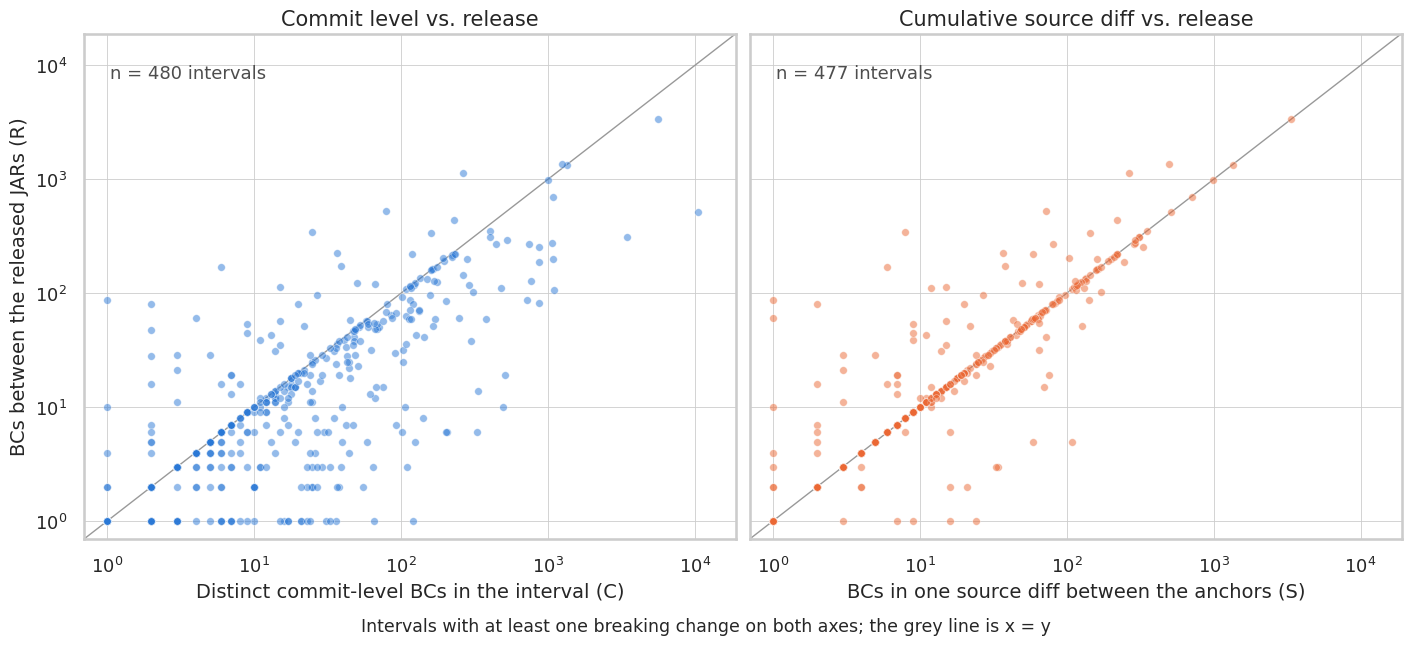

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True, layout="constrained")
lim = (0.7, max(usable.commit_keys.max(), usable.release_keys.max()) * 1.8)

for ax, (x, xlabel, colour) in zip(axes, [
        ("commit_keys", "Distinct commit-level BCs in the interval (C)", BLUE),
        ("source_keys", "BCs in one source diff between the anchors (S)", ORANGE)]):
    d = usable[(usable[x] > 0) & (usable.release_keys > 0)]
    ax.plot(lim, lim, color="0.6", lw=1, zorder=1)
    ax.scatter(d[x], d.release_keys, s=30, color=colour, alpha=0.5,
               linewidth=0.5, edgecolor="white", zorder=2)
    ax.set(xscale="log", yscale="log", xlim=lim, ylim=lim)
    ax.set_xlabel(xlabel, fontsize=14)
    ax.tick_params(labelsize=13)
    ax.grid(True, which="major", lw=0.6)
    ax.annotate(f"n = {len(d)} intervals", xy=(0.04, 0.94), xycoords="axes fraction",
                fontsize=13, color="0.3", va="top")

axes[0].set_ylabel("BCs between the released JARs (R)", fontsize=14)
axes[0].set_title("Commit level vs. release", fontsize=15)
axes[1].set_title("Cumulative source diff vs. release", fontsize=15)
fig.suptitle("Intervals with at least one breaking change on both axes; the grey line is x = y",
             fontsize=12.5, y=-0.02)
fig.savefig(FIG_DIR / "commit-vs-release.pdf", bbox_inches="tight")
plt.show()

The left panel sits well above the diagonal — the commit stream carries far more breaking changes
than the release pair does. The right panel is tight on the diagonal: **a single cumulative source
diff between the two release commits reproduces the released JAR diff almost exactly.** Source and
bytecode analysis agree; what separates `C` from `R` is granularity plus what the build ships.

The decomposition below puts a number on each outcome.

In [8]:
fate = pd.DataFrame({
    "released (C∩R)": [usable.commit_and_release.sum()],
    "still in the source at release time, absent from the JAR (C∩S∖R)":
        [(usable.commit_and_source - usable.commit_and_release).clip(lower=0).sum()],
})
fate["cancelled inside the interval (C∖S∖R)"] = usable.commit_keys.sum() - fate.sum(axis=1)
fate = fate.T.rename(columns={0: "distinct BCs"})
fate["share"] = (fate["distinct BCs"] / fate["distinct BCs"].sum()).map("{:.1%}".format)
display(fate)

provenance = pd.DataFrame({
    "attributable to a walked commit (R∩C)": [usable.commit_and_release.sum()],
    "only in the cumulative source diff (R∩S∖C)":
        [(usable.source_and_release - usable.commit_and_release).clip(lower=0).sum()],
})
provenance["in neither — not in the walked source tree (R∖S∖C)"] = (
    usable.release_keys.sum() - provenance.sum(axis=1))
provenance = provenance.T.rename(columns={0: "distinct BCs"})
provenance["share"] = (provenance["distinct BCs"] / provenance["distinct BCs"].sum()).map("{:.1%}".format)
display(provenance)

,distinct BCs,share
released (C∩R),19745,36.2%
"still in the source at release time, absent from the JAR (C∩S∖R)",1570,2.9%
cancelled inside the interval (C∖S∖R),33165,60.9%


,distinct BCs,share
attributable to a walked commit (R∩C),19745,77.4%
only in the cumulative source diff (R∩S∖C),195,0.8%
in neither — not in the walked source tree (R∖S∖C),5564,21.8%


The residual `R∖S∖C` — released breaking changes that appear in neither the commit stream nor the
source diff — is concentrated in a handful of libraries, and every case is a **build-time
transformation of the artefact**, not a Roseau disagreement:

| library | share of the residual | why |
|---|---|---|
| `mysql-connector-j` | 54% | the artefact is built from `src/main/{protocol,user}-impl/java` too; the walk's `sourceRoots` only cover `core-api` |
| `lombok` | 15% | the released JAR is shaded and post-processed (`lombok.libs.org.objectweb.asm`, vendored `com.sun.jna`) |
| `assertj-core` | 11% | 3.12.0 shades ByteBuddy *and its `module-info`*, so the JAR advertises `module net.bytebuddy` and Roseau reads only ByteBuddy's packages as exported |
| `protobuf-java` | 7% | `com.google.protobuf` descriptor classes are generated by `protoc` during the build |
| `mockito-core` | 4% | shaded `org.mockito.cglib` / `org.mockito.asm` |

Each is a way in which the published artefact is not the analysed source tree.

## 4. Which kinds of breaking change survive?

`comparison-tagged-fate-by-kind.csv` classifies every distinct commit-level breaking change by what
became of it at the next release.

In [9]:
fate_by_kind = pd.read_csv(DATA_DIR / "comparison-tagged-fate-by-kind.csv").set_index("kind")
fate_by_kind["total"] = fate_by_kind.sum(axis=1)
fate_by_kind["released_share"] = fate_by_kind.released / fate_by_kind.total
display(fate_by_kind.sort_values("total", ascending=False).head(15).round(3))

,released,in_source_not_in_jar,cancelled_before_release,total,released_share
kind,,,,,
EXECUTABLE_REMOVED,6221,815,16740,23776,0.262
METHOD_RETURN_TYPE_CHANGED_INCOMPATIBLE,2264,139,2605,5008,0.452
METHOD_NOW_FINAL,2284,42,2547,4873,0.469
TYPE_REMOVED,2492,338,1748,4578,0.544
METHOD_RETURN_TYPE_ERASURE_CHANGED,1919,113,1826,3858,0.497
FIELD_REMOVED,1595,29,1059,2683,0.594
TYPE_NEW_ABSTRACT_METHOD,722,66,1322,2110,0.342
EXECUTABLE_PARAMETER_GENERICS_CHANGED,683,51,1191,1925,0.355
TYPE_SUPERTYPE_REMOVED,421,69,922,1412,0.298


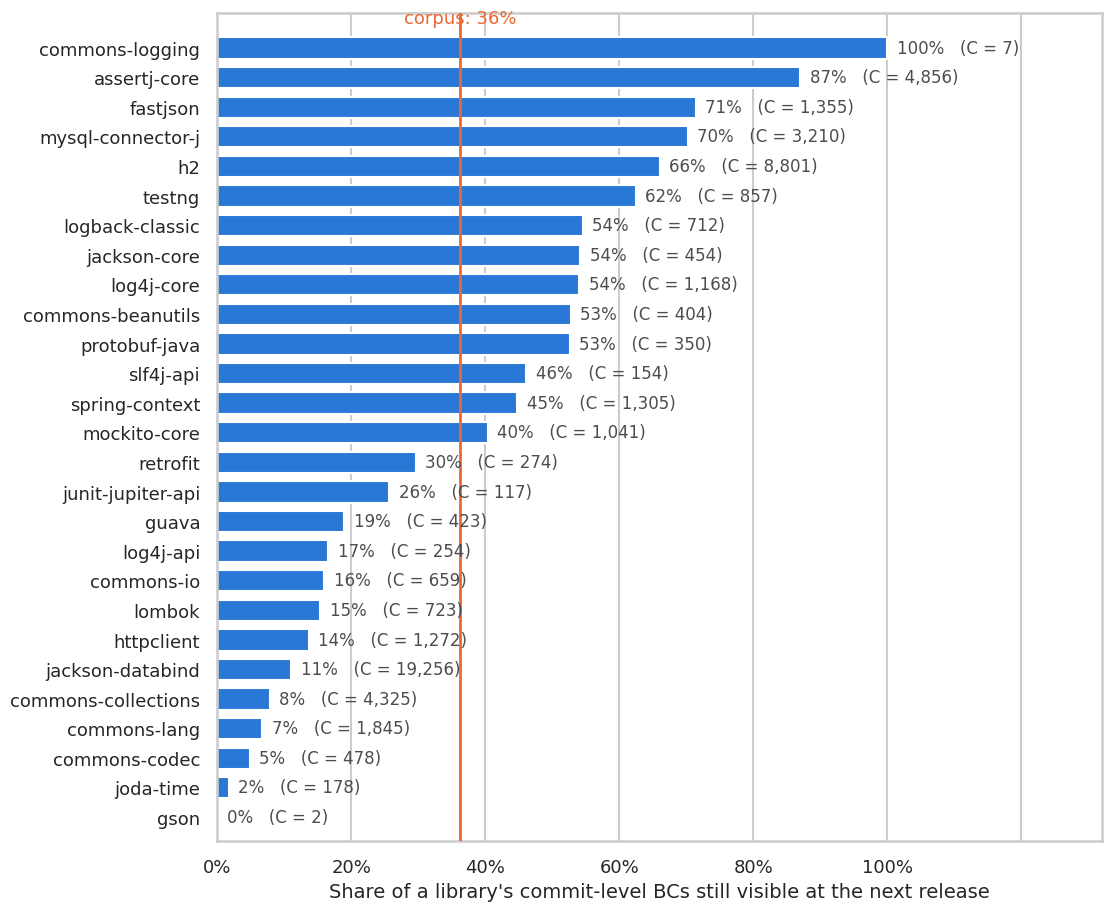

In [10]:
lib_survival = (usable.groupby("library")
                .agg(C=("commit_keys", "sum"), CR=("commit_and_release", "sum"),
                     R=("release_keys", "sum"))
                .query("C > 0"))
lib_survival["survival"] = lib_survival.CR / lib_survival.C
lib_survival = lib_survival.sort_values("survival")

fig, ax = plt.subplots(figsize=(11, 9), layout="constrained")
ax.barh(lib_survival.index, lib_survival.survival, color=BLUE, height=0.72)
overall = usable.commit_and_release.sum() / usable.commit_keys.sum()
ax.axvline(overall, color=ORANGE, lw=2, zorder=3)
ax.annotate(f"corpus: {overall:.0%}", xy=(overall, len(lib_survival) - 0.3), color=ORANGE,
            fontsize=13, ha="center", va="bottom")
for lib, r in lib_survival.iterrows():
    ax.annotate(f"{r.survival:.0%}   (C = {int(r.C):,})", xy=(r.survival, lib),
                xytext=(7, 0), textcoords="offset points", va="center",
                fontsize=12, color="0.3")
ax.set(xlim=(0, 1.32), ylim=(-0.8, len(lib_survival) + 0.2))
ax.set_xlabel("Share of a library's commit-level BCs still visible at the next release",
              fontsize=14)
ax.xaxis.set_major_formatter(lambda x, _: f"{x:.0%}" if x <= 1 else "")
ax.tick_params(labelsize=13)
ax.grid(axis="y", visible=False)
fig.savefig(FIG_DIR / "bc-survival-by-library.pdf", bbox_inches="tight")
plt.show()

## 5. Sensitivity

Two robustness checks on the two decisions that could plausibly drive the numbers: which intervals
are trusted, and how a breaking change is identified across the two sides.

In [11]:
variants = {
    "tag-anchored intervals, exact signature": comparison,
    "tag-anchored intervals, generics-erased signature": comparison_erased,
    "all mainline intervals, exact signature": comparison_all,
}
rows = []
for name, df in variants.items():
    u = df[df.has_jar_diff & df.has_source_diff]
    rows.append({
        "variant": name, "intervals": len(u),
        "C events / released BC": round(u.commit_events.sum() / u.release_keys.sum(), 2),
        "survival C∩R/C": round(u.commit_and_release.sum() / u.commit_keys.sum(), 3),
        "coverage C∩R/R": round(u.commit_and_release.sum() / u.release_keys.sum(), 3),
        "coverage S∩R/R": round(u.source_and_release.sum() / u.release_keys.sum(), 3),
    })
display(pd.DataFrame(rows).set_index("variant"))

,intervals,C events / released BC,survival C∩R/C,coverage C∩R/R,coverage S∩R/R
variant,,,,,
"tag-anchored intervals, exact signature",1233,8.77,0.362,0.774,0.767
"tag-anchored intervals, generics-erased signature",1233,9.04,0.357,0.774,0.766
"all mainline intervals, exact signature",1453,7.33,0.361,0.730,0.726


Both checks move the headline numbers by at most a couple of points, so neither the interval
filter nor the signature-matching rule is driving the result.

**In summary.** A cumulative source diff and a JAR diff over the same interval agree to within
0.7 pp, so Roseau's two extractors can be used interchangeably on these libraries. The residual
22 % is accounted for by build-time construction of the artefact rather than by any disagreement
between them.